# 📈 Stock Market Analytics — CodeAlpha Data Analytics Internship

**Name:** Your Name
**Internship:** CodeAlpha — Data Analytics
**GitHub Repo:** `CodeAlpha_StockMarketAnalytics`
**Dataset:** S&P 500 Stock Data 2013–2018 (Kaggle)

---

| Task | Description |
|------|-------------|
| ✅ Task 1 | **Data Collection** — Load & inspect S&P 500 stock dataset |
| ✅ Task 2 | **EDA** — Price trends, volatility, correlations |
| ✅ Task 3 | **Data Visualization** — Charts & dashboard |
| ✅ Task 4 | **Sentiment Analysis** — Financial news headlines |

---

## ⚙️ Install & Import Libraries

In [1]:
!pip install textblob vaderSentiment --quiet
!python -m textblob.download_corpora --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, re, time, requests
from bs4 import BeautifulSoup
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)
print('✅ All libraries ready!')

✅ All libraries ready!


---
#   Data Collection & Loading
>
> Dataset: https://www.kaggle.com/datasets/camnugent/sandp500

In [4]:
from google.colab import files
print("Please upload all_stocks_5yr.csv")
uploaded = files.upload()

Please upload all_stocks_5yr.csv


Saving all_stocks_5yr.csv to all_stocks_5yr.csv


In [5]:
import io

df = pd.read_csv(io.BytesIO(uploaded['all_stocks_5yr.csv']))

print(f'✅ Dataset loaded! Shape: {df.shape}')
print()
print('── Columns ──')
print(list(df.columns))
print()
print('── Sample Data ──')
display(df.head(10))

✅ Dataset loaded! Shape: (619040, 7)

── Columns ──
['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

── Sample Data ──


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
5,2013-02-15,13.93,14.61,13.93,14.50,15628000,AAL
6,2013-02-19,14.33,14.56,14.08,14.26,11354400,AAL
7,2013-02-20,14.17,14.26,13.15,13.33,14725200,AAL
8,2013-02-21,13.62,13.95,12.90,13.37,11922100,AAL
9,2013-02-22,13.57,13.60,13.21,13.57,6071400,AAL


In [6]:

print('── Dataset Info ──')
df.info()

── Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [7]:

df['date'] = pd.to_datetime(df['date'])
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print('── Date Range ──')
print(f'From : {df["date"].min().date()}')
print(f'To   : {df["date"].max().date()}')
print(f'Total Companies : {df["Name"].nunique()}')
print(f'Total Records   : {len(df):,}')

── Date Range ──
From : 2013-02-08
To   : 2018-02-07
Total Companies : 505
Total Records   : 619,040


In [8]:

print('── Missing Values ──')
mv = df.isnull().sum()
print(mv[mv > 0].to_string() if mv.any() else '  No missing values ✅')

# Drop missing rows
df.dropna(inplace=True)
print(f'\nClean dataset shape: {df.shape}')
df.to_csv('stocks_clean.csv', index=False)
print('✅ Task 1 Complete — Data saved as stocks_clean.csv')

── Missing Values ──
open    11
high     8
low      8

Clean dataset shape: (619029, 9)
✅ Task 1 Complete — Data saved as stocks_clean.csv


---
#   Exploratory Data Analysis (EDA)
> Understand stock price trends, volatility, correlations and test hypotheses.

In [9]:
print('='*55)
print('  DATASET OVERVIEW')
print('='*55)
print(f'Total Records    : {len(df):,}')
print(f'Total Companies  : {df["Name"].nunique()}')
print(f'Date Range       : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Years Covered    : {sorted(df["year"].unique())}')

  DATASET OVERVIEW
Total Records    : 619,029
Total Companies  : 505
Date Range       : 2013-02-08 → 2018-02-07
Years Covered    : [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [10]:

print('── Descriptive Statistics ──')
display(df[['open','high','low','close','volume']].describe().round(2))

── Descriptive Statistics ──


,open,high,low,close,volume
count,619029.00,619029.00,619029.00,619029.00,6.190290e+05
mean,83.02,83.78,82.26,83.04,4.321892e+06
std,97.38,98.21,96.51,97.39,8.693671e+06
min,1.62,1.69,1.50,1.59,1.010000e+02
25%,40.22,40.62,39.83,40.24,1.070351e+06
50%,62.59,63.15,62.02,62.62,2.082165e+06
75%,94.37,95.18,93.54,94.41,4.284550e+06
max,2044.00,2067.99,2035.11,2049.00,6.182376e+08


In [11]:

top_volume = df.groupby('Name')['volume'].mean().sort_values(ascending=False).head(10).reset_index()
top_volume.columns = ['Company', 'Avg_Volume']
top_volume.index += 1
print('── Top 10 Most Traded Stocks (by Average Volume) ──')
display(top_volume)

── Top 10 Most Traded Stocks (by Average Volume) ──


,Company,Avg_Volume
1,BAC,9.363380e+07
2,AAPL,5.404790e+07
3,GE,4.211568e+07
4,F,3.446237e+07
5,FB,3.435927e+07
6,MSFT,3.386946e+07
7,AMD,3.251904e+07
8,MU,3.024841e+07
9,INTC,2.932671e+07
10,CSCO,2.865435e+07


In [12]:

top_price = df.groupby('Name')['close'].mean().sort_values(ascending=False).head(10).reset_index()
top_price.columns = ['Company', 'Avg_Close_Price']
top_price.index += 1
print('── Top 10 Highest Average Stock Prices ──')
display(top_price)

── Top 10 Highest Average Stock Prices ──


,Company,Avg_Close_Price
1,PCLN,1312.873538
2,GOOG,725.403353
3,GOOGL,682.233847
4,AZO,619.703654
5,AMZN,576.880041
6,CMG,493.256008
7,REGN,381.718428
8,MTD,356.297498
9,BLK,348.628967
10,BIIB,295.413264


In [13]:

df = df.sort_values(['Name','date'])
df['daily_return'] = df.groupby('Name')['close'].pct_change() * 100

print('── Daily Return Statistics ──')
display(df['daily_return'].describe().round(4))

── Daily Return Statistics ──


,daily_return
count,618524.0000
mean,0.0541
std,1.6060
min,-62.6183
25%,-0.6793
50%,0.0635
75%,0.8105
max,100.9513


In [14]:

volatility = df.groupby('Name')['daily_return'].std().sort_values(ascending=False).head(10).reset_index()
volatility.columns = ['Company', 'Volatility']
volatility.index += 1
print('── Top 10 Most Volatile Stocks ──')
display(volatility)

── Top 10 Most Volatile Stocks ──


,Company,Volatility
1,CHK,4.165753
2,AMD,3.778425
3,BHGE,3.521895
4,FCX,3.412276
5,LNT,3.337309
6,VRTX,3.211578
7,INCY,2.977661
8,MRO,2.973891
9,WMB,2.955939
10,EVHC,2.856106


In [15]:

first_price = df.groupby('Name')['close'].first()
last_price  = df.groupby('Name')['close'].last()
performance = ((last_price - first_price) / first_price * 100).sort_values(ascending=False)
top_gainers = performance.head(10).reset_index()
top_gainers.columns = ['Company', 'Total_Return_%']
top_gainers['Total_Return_%'] = top_gainers['Total_Return_%'].round(2)
top_gainers.index += 1
print('── Top 10 Best Performing Stocks (2013–2018) ──')
display(top_gainers)

── Top 10 Best Performing Stocks (2013–2018) ──


,Company,Total_Return_%
1,NVDA,1749.64
2,NFLX,923.33
3,ALGN,615.95
4,EA,608.41
5,STZ,572.37
6,AVGO,572.08
7,FB,531.21
8,MU,442.06
9,AMZN,440.86
10,ATVI,417.97


In [16]:

top_losers = performance.tail(10).reset_index()
top_losers.columns = ['Company', 'Total_Return_%']
top_losers['Total_Return_%'] = top_losers['Total_Return_%'].round(2)
top_losers.index += 1
print('── Top 10 Worst Performing Stocks (2013–2018) ──')
display(top_losers)

── Top 10 Worst Performing Stocks (2013–2018) ──


,Company,Total_Return_%
1,APA,-53.28
2,KMI,-54.02
3,MAT,-57.84
4,CTL,-58.75
5,MOS,-58.88
6,DISCK,-66.02
7,DISCA,-67.65
8,UA,-72.40
9,RRC,-81.82
10,CHK,-85.71


── Correlation Matrix ──


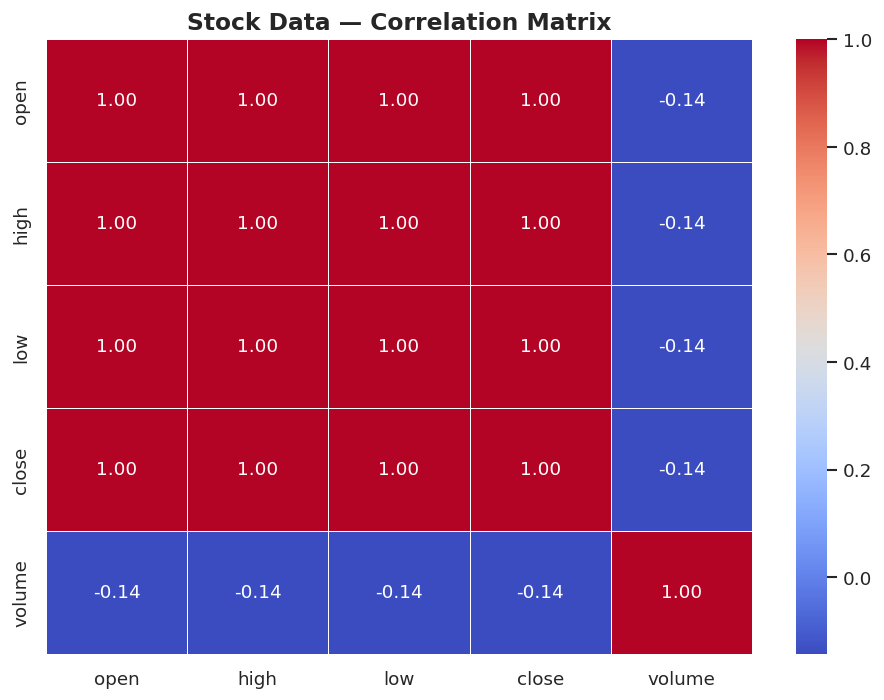

In [17]:

print('── Correlation Matrix ──')
corr = df[['open','high','low','close','volume']].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, annot_kws={'size':11})
ax.set_title('Stock Data — Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

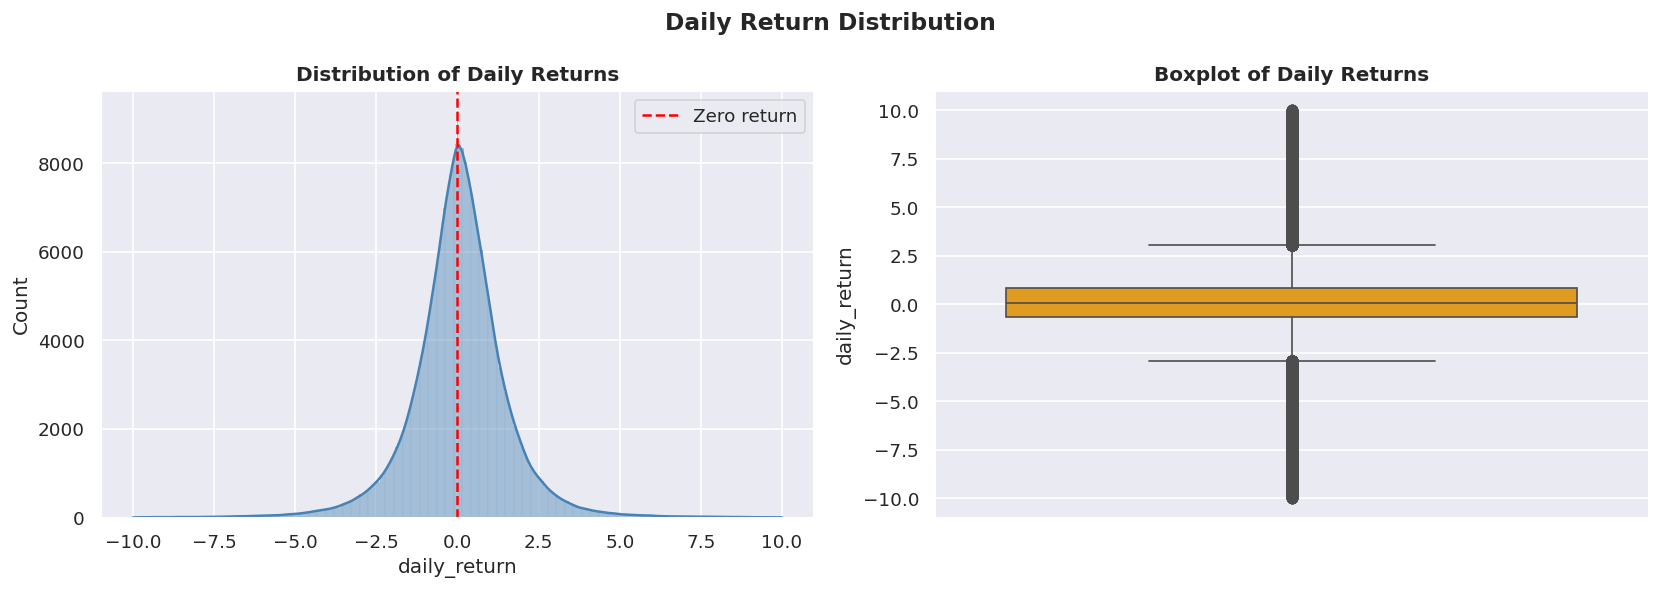

In [18]:

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Daily Return Distribution', fontsize=14, fontweight='bold')

returns = df['daily_return'].dropna()
returns_clipped = returns[(returns > -10) & (returns < 10)]  # remove extreme outliers for clarity

sns.histplot(returns_clipped, kde=True, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Daily Returns', fontweight='bold')
axes[0].axvline(0, color='red', ls='--', lw=1.5, label='Zero return')
axes[0].legend()

sns.boxplot(y=returns_clipped, ax=axes[1], color='orange')
axes[1].set_title('Boxplot of Daily Returns', fontweight='bold')
plt.tight_layout(); plt.show()

In [19]:

print('📊 HYPOTHESIS TESTING')
print('='*55)

c1 = df[['open','close']].corr().iloc[0,1]
print(f'H1: Opening price predicts Closing price?  Corr: {c1:.4f}')
print(f'   → {"Very strong! Opening price is a great predictor of closing price" if c1>0.99 else "Strong positive correlation"}')

c2 = df[['volume','daily_return']].corr().iloc[0,1]
print(f'\nH2: Higher Volume = Higher Daily Return?  Corr: {c2:.4f}')
print(f'   → {"Weak/no relationship — volume alone does not predict returns" if abs(c2)<0.1 else "Some relationship exists"}')

avg_ret = df['daily_return'].mean()
print(f'\nH3: Do stocks generally go up over time?')
print(f'   Average daily return: {avg_ret:.4f}%')
print(f'   → {"Yes! Positive average daily return confirms overall upward trend" if avg_ret>0 else "Negative average return over this period"}')

📊 HYPOTHESIS TESTING
H1: Opening price predicts Closing price?  Corr: 0.9999
   → Very strong! Opening price is a great predictor of closing price

H2: Higher Volume = Higher Daily Return?  Corr: -0.0065
   → Weak/no relationship — volume alone does not predict returns

H3: Do stocks generally go up over time?
   Average daily return: 0.0541%
   → Yes! Positive average daily return confirms overall upward trend


---
#  Data Visualization
> Build compelling charts and a master dashboard from the stock market data.

In [20]:
STOCK_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

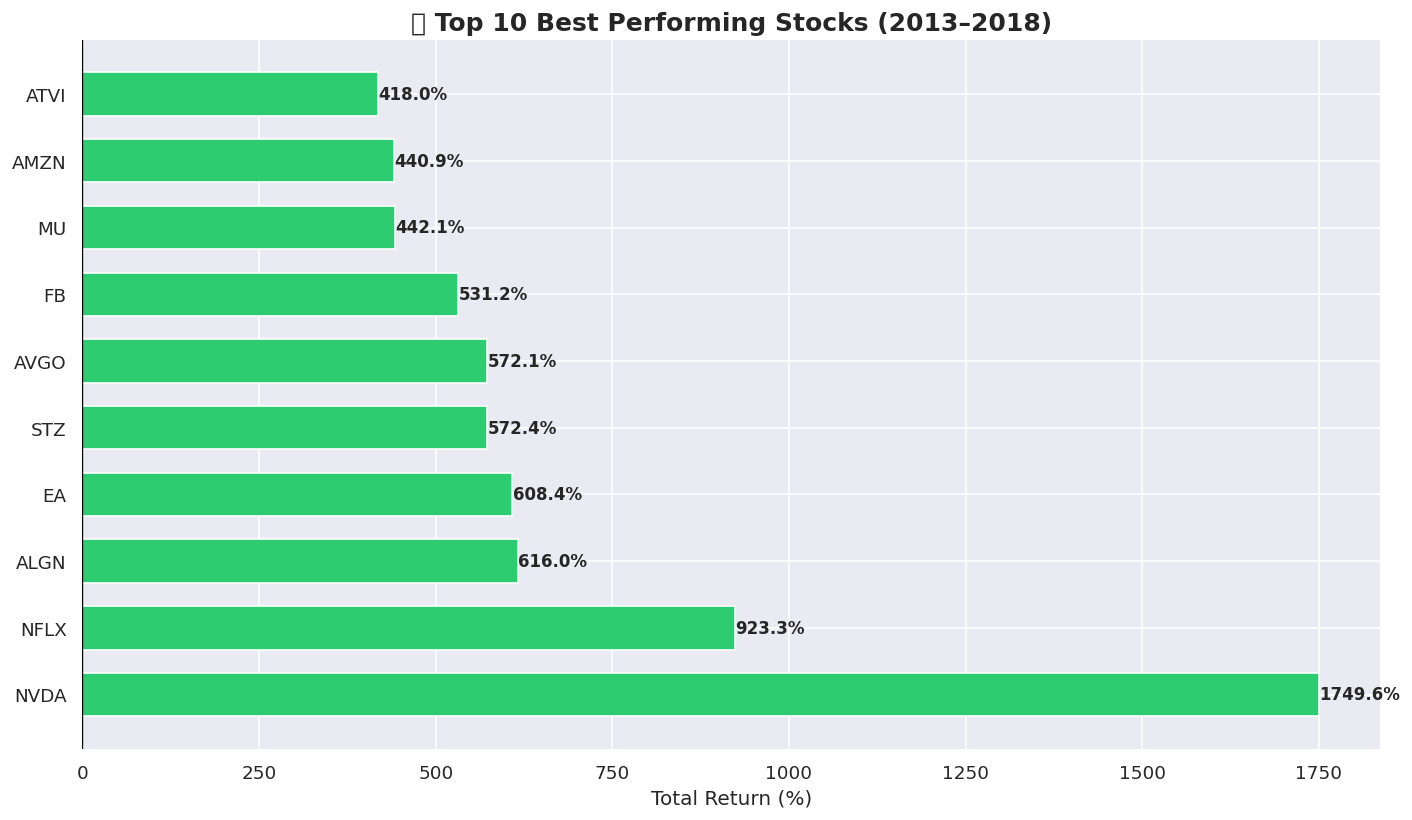

In [21]:

fig, ax = plt.subplots(figsize=(12,7))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_gainers['Total_Return_%']]
bars = ax.barh(top_gainers['Company'], top_gainers['Total_Return_%'],
               color=colors, edgecolor='white', height=0.65)
for bar, val in zip(bars, top_gainers['Total_Return_%']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Total Return (%)', fontsize=12)
ax.set_title('📈 Top 10 Best Performing Stocks (2013–2018)', fontsize=15, fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

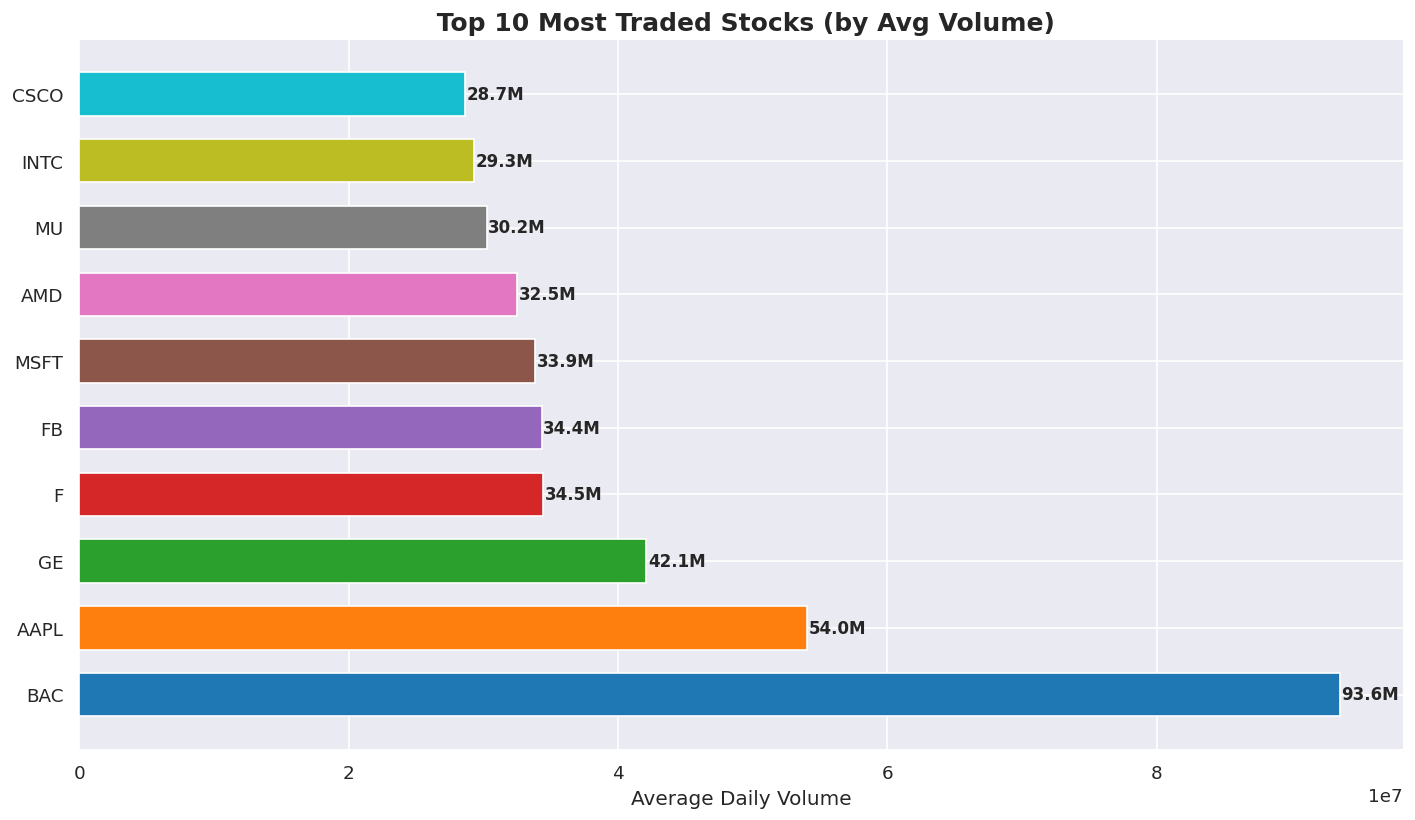

In [22]:

fig, ax = plt.subplots(figsize=(12,7))
bars = ax.barh(top_volume['Company'], top_volume['Avg_Volume'],
               color=STOCK_COLORS, edgecolor='white', height=0.65)
for bar, val in zip(bars, top_volume['Avg_Volume']):
    ax.text(bar.get_width()+100000, bar.get_y()+bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', ha='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Average Daily Volume', fontsize=12)
ax.set_title(' Top 10 Most Traded Stocks (by Avg Volume)', fontsize=15, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

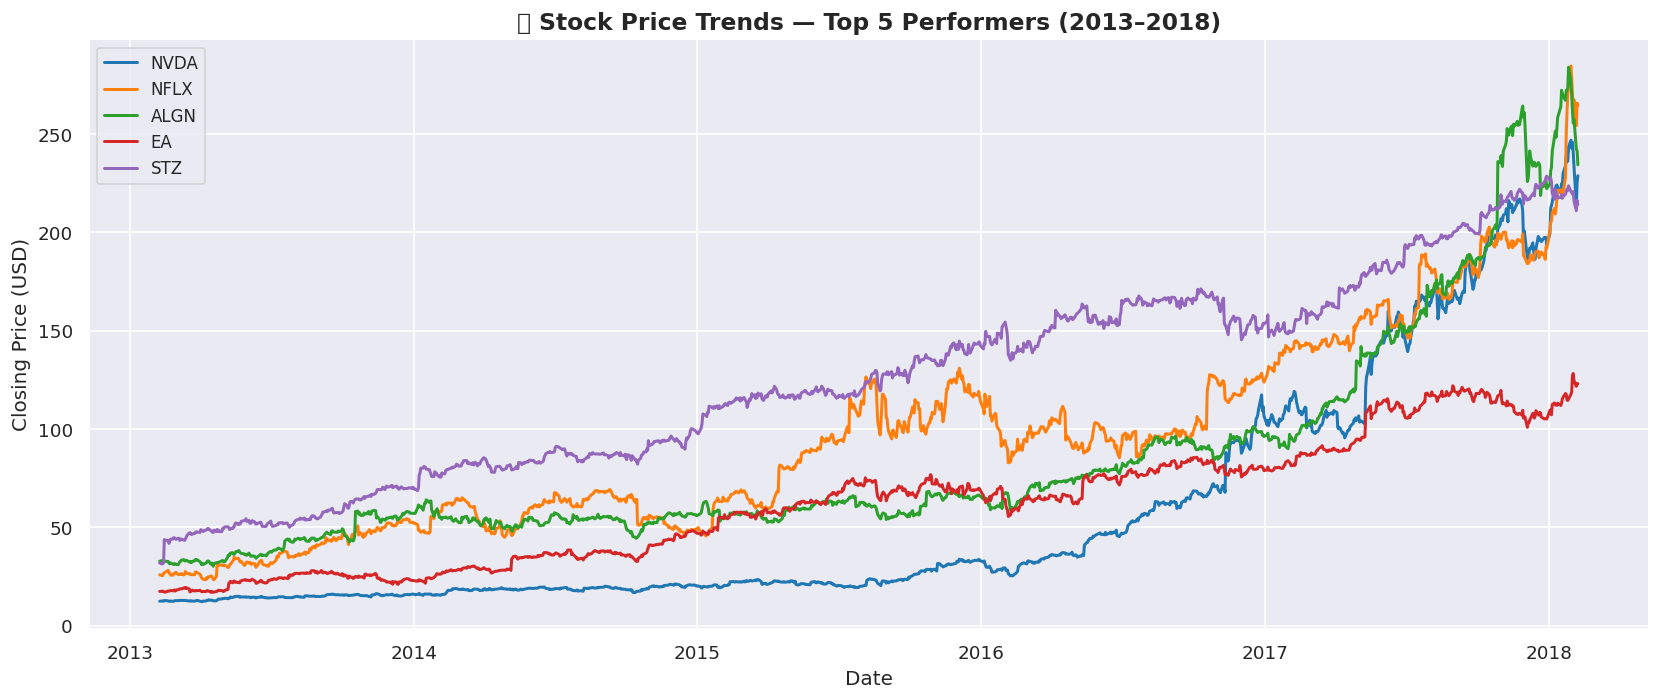

In [23]:

top5 = top_gainers['Company'].head(5).tolist()
fig, ax = plt.subplots(figsize=(14,6))
for i, company in enumerate(top5):
    company_data = df[df['Name'] == company].sort_values('date')
    ax.plot(company_data['date'], company_data['close'],
            label=company, linewidth=1.8, color=STOCK_COLORS[i])
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Closing Price (USD)', fontsize=12)
ax.set_title('📅 Stock Price Trends — Top 5 Performers (2013–2018)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

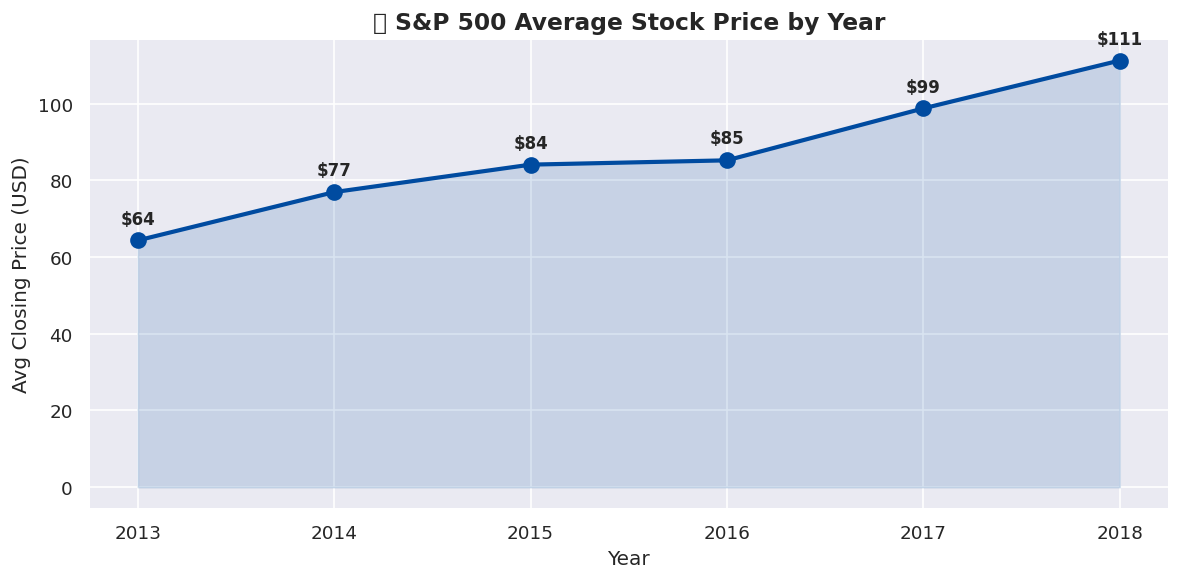

In [24]:

yearly_avg = df.groupby('year')['close'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(yearly_avg['year'], yearly_avg['close'],
        marker='o', linewidth=2.5, markersize=9, color='#004BA0')
ax.fill_between(yearly_avg['year'], yearly_avg['close'], alpha=0.15, color='#004BA0')
for _, row in yearly_avg.iterrows():
    ax.annotate(f"${row['close']:.0f}", (row['year'], row['close']),
                textcoords='offset points', xytext=(0,10),
                ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Closing Price (USD)', fontsize=12)
ax.set_title('📈 S&P 500 Average Stock Price by Year', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

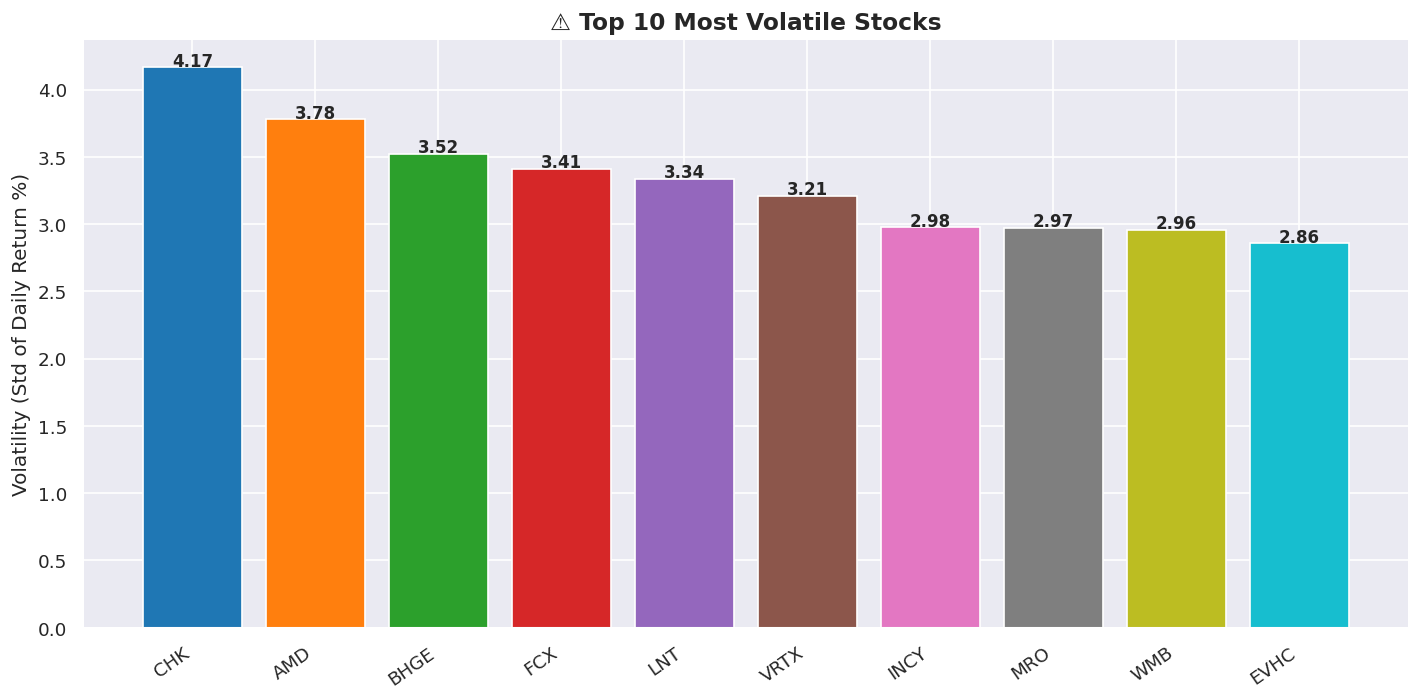

In [25]:

fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(volatility['Company'], volatility['Volatility'],
              color=STOCK_COLORS, edgecolor='white')
for bar, val in zip(bars, volatility['Volatility']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.2f}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Volatility (Std of Daily Return %)', fontsize=12)
ax.set_title('⚠️ Top 10 Most Volatile Stocks', fontsize=14, fontweight='bold')
ax.set_xticklabels(volatility['Company'], rotation=35, ha='right')
plt.tight_layout(); plt.show()

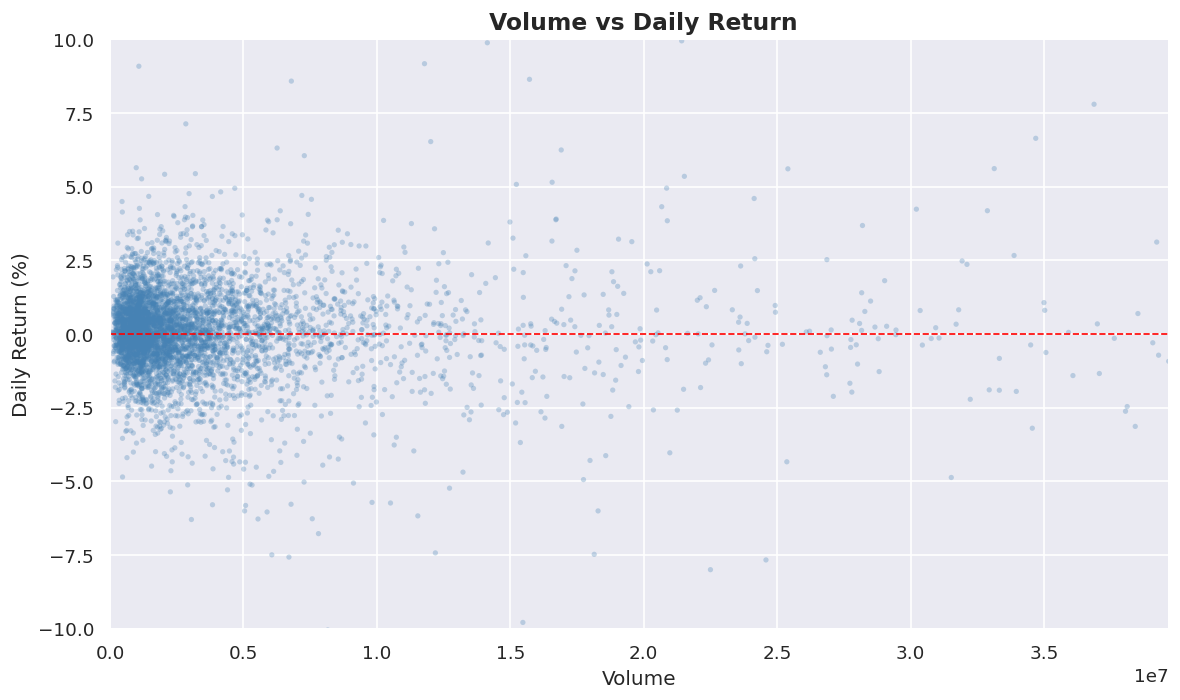

In [26]:

sample = df[df['daily_return'].notna()].sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(sample['volume'], sample['daily_return'],
           alpha=0.3, s=10, color='steelblue', edgecolors='none')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xlabel('Volume', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_title(' Volume vs Daily Return', fontsize=14, fontweight='bold')
ax.set_xlim(0, sample['volume'].quantile(0.99))
ax.set_ylim(-10, 10)
plt.tight_layout(); plt.show()

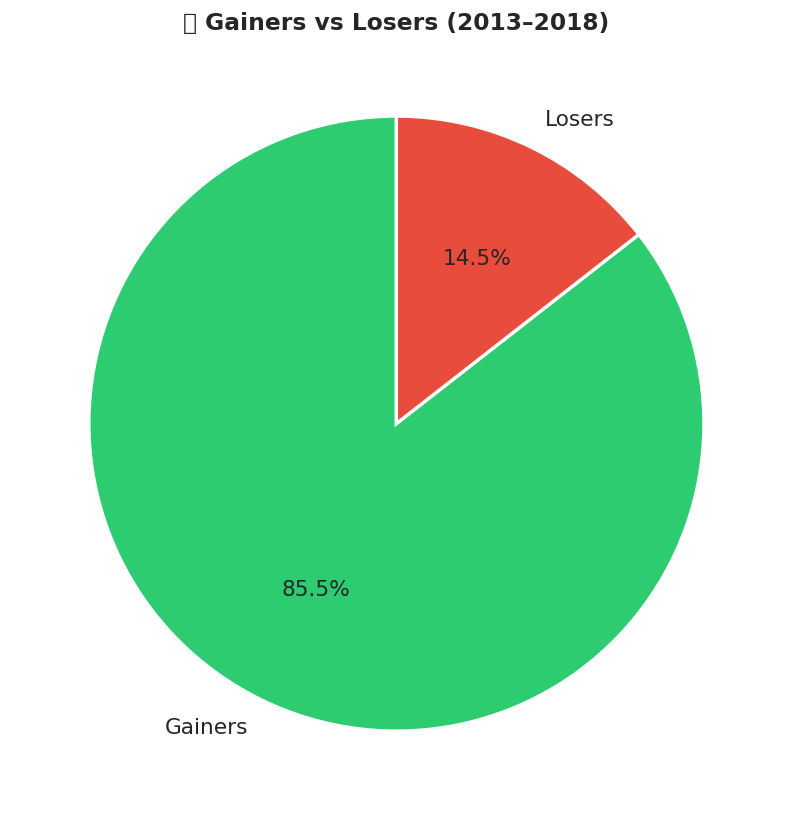

In [27]:

gainers = (performance > 0).sum()
losers  = (performance <= 0).sum()
fig, ax = plt.subplots(figsize=(7,7))
ax.pie([gainers, losers], labels=['Gainers', 'Losers'],
       autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
       wedgeprops={'edgecolor':'white','linewidth':2},
       textprops={'fontsize':13}, startangle=90)
ax.set_title('📊 Gainers vs Losers (2013–2018)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

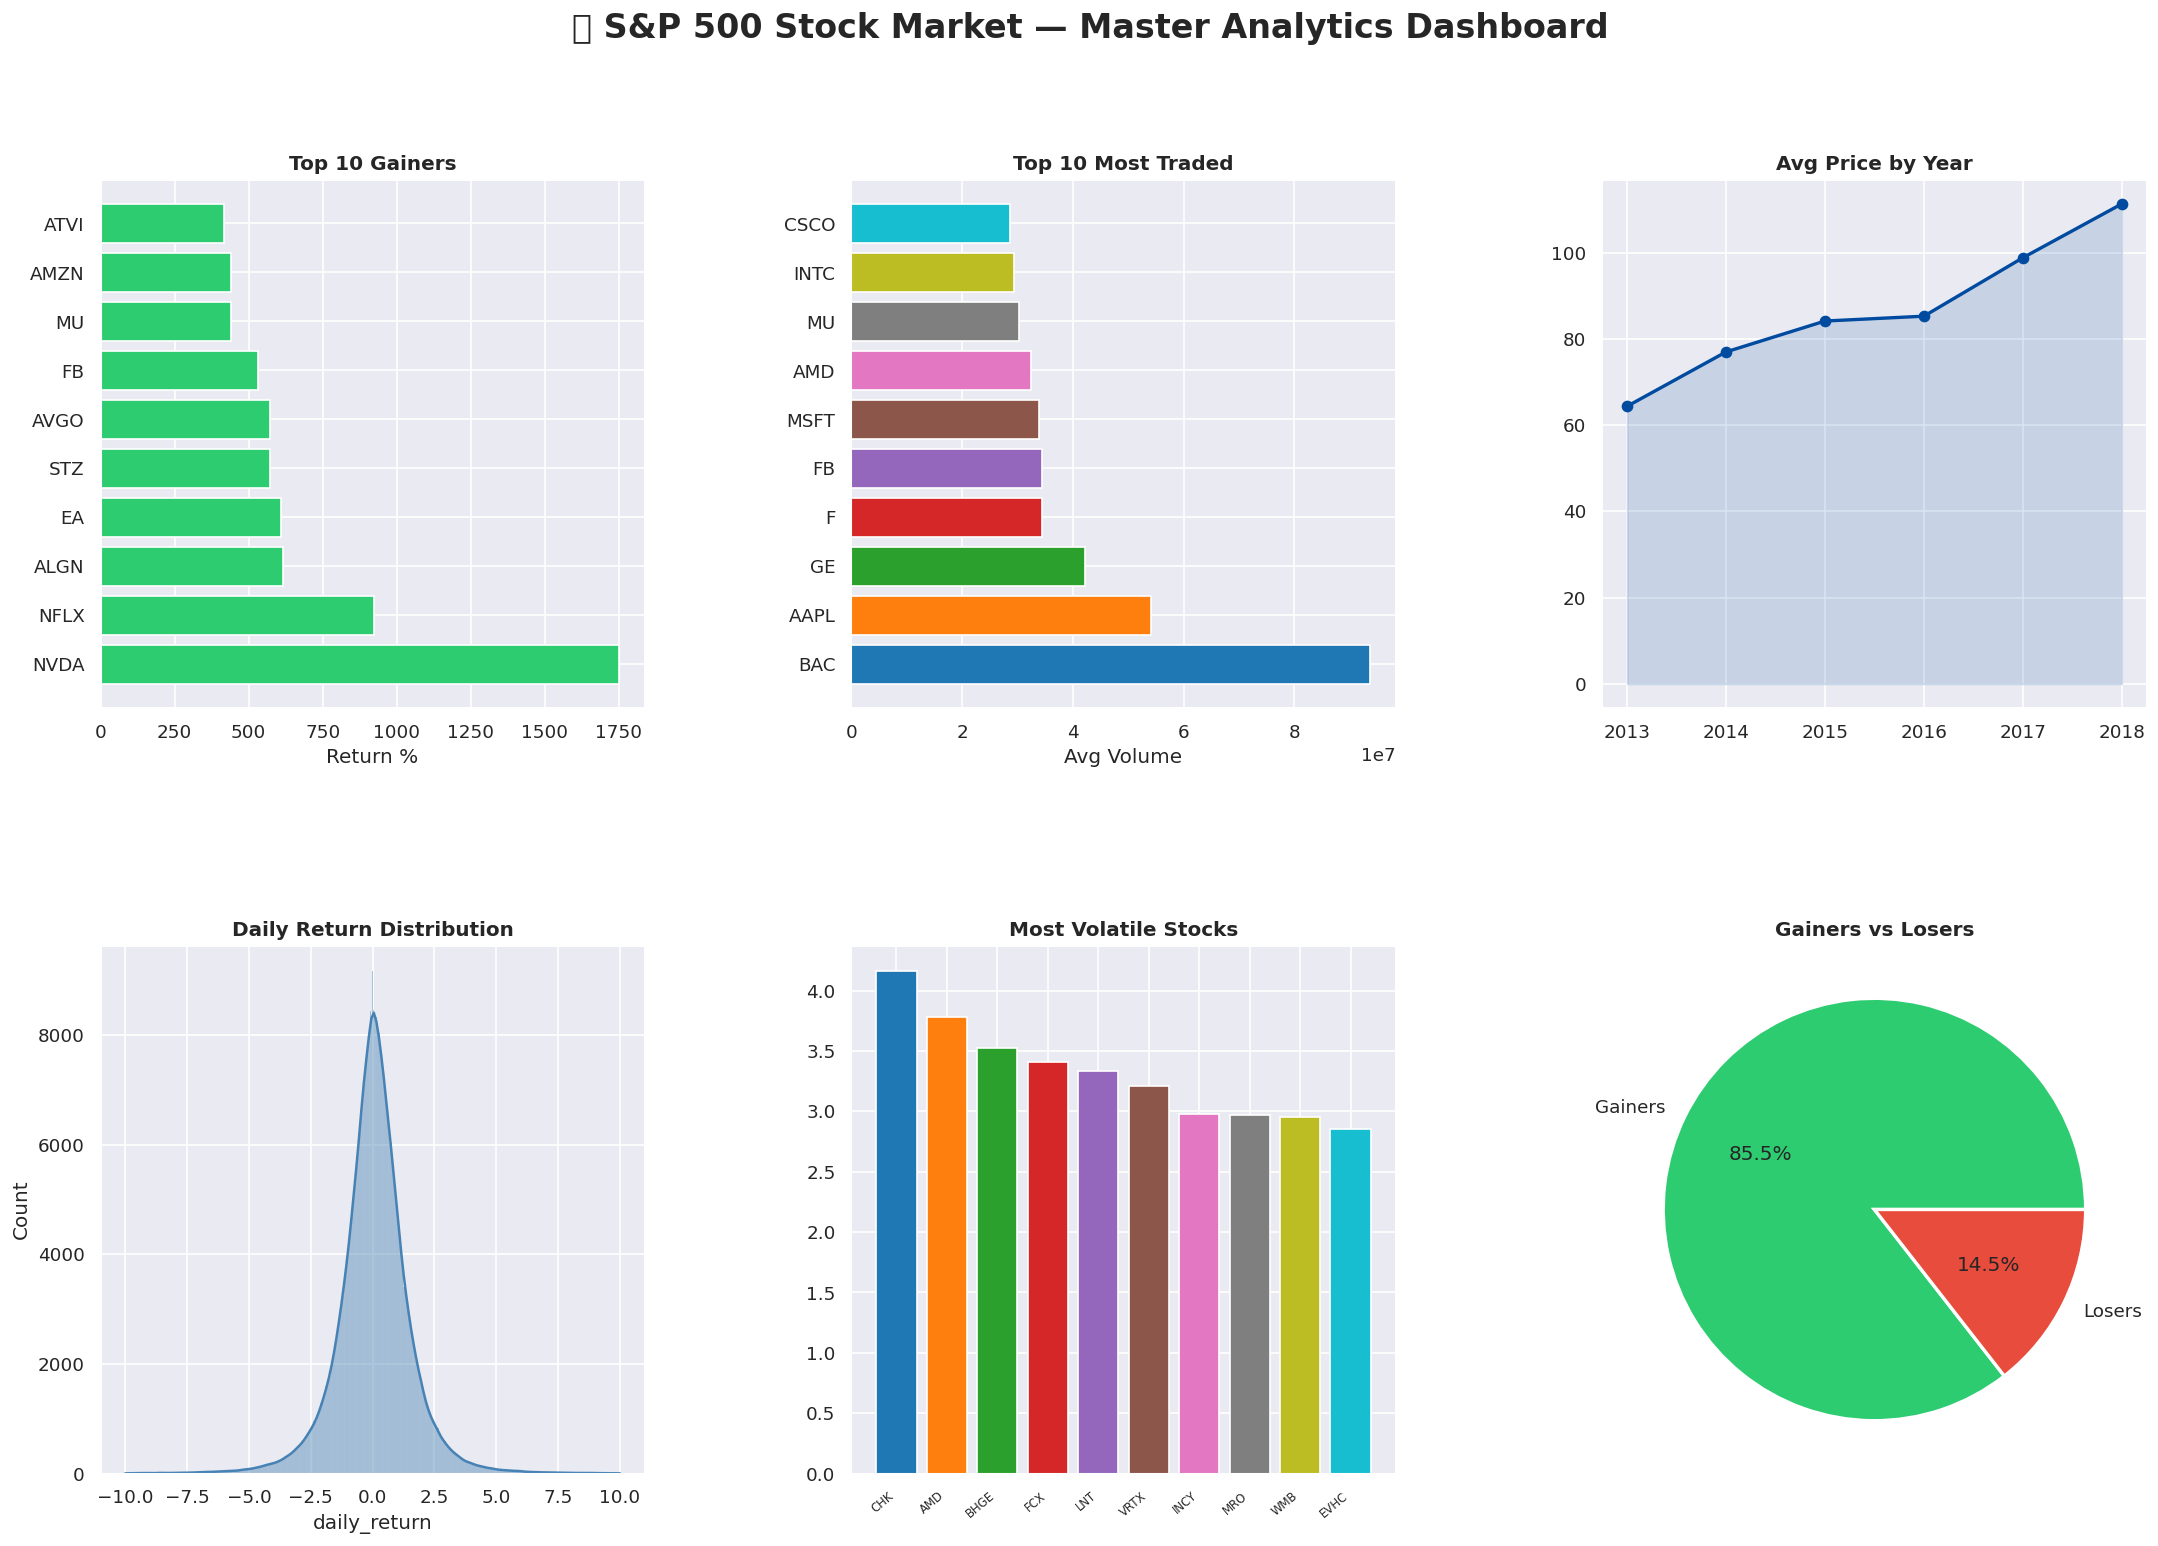

 Dashboard saved as stocks_dashboard.png


In [28]:

fig = plt.figure(figsize=(22,14))
fig.suptitle('📈 S&P 500 Stock Market — Master Analytics Dashboard', fontsize=20, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.38)

ax1 = fig.add_subplot(gs[0,0])
ax1.barh(top_gainers['Company'], top_gainers['Total_Return_%'],
         color=['#2ecc71' if x>0 else '#e74c3c' for x in top_gainers['Total_Return_%']])
ax1.set_title('Top 10 Gainers', fontweight='bold'); ax1.set_xlabel('Return %')


ax2 = fig.add_subplot(gs[0,1])
ax2.barh(top_volume['Company'], top_volume['Avg_Volume'], color=STOCK_COLORS[:10])
ax2.set_title('Top 10 Most Traded', fontweight='bold'); ax2.set_xlabel('Avg Volume')


ax3 = fig.add_subplot(gs[0,2])
ax3.plot(yearly_avg['year'], yearly_avg['close'], marker='o', color='#004BA0', lw=2)
ax3.fill_between(yearly_avg['year'], yearly_avg['close'], alpha=0.15, color='#004BA0')
ax3.set_title('Avg Price by Year', fontweight='bold')

ax4 = fig.add_subplot(gs[1,0])
returns_clipped = df['daily_return'].dropna()
returns_clipped = returns_clipped[(returns_clipped>-10) & (returns_clipped<10)]
sns.histplot(returns_clipped, kde=True, ax=ax4, color='steelblue', edgecolor='white')
ax4.set_title('Daily Return Distribution', fontweight='bold')


ax5 = fig.add_subplot(gs[1,1])
ax5.bar(volatility['Company'], volatility['Volatility'], color=STOCK_COLORS, edgecolor='white')
ax5.set_xticklabels(volatility['Company'], rotation=40, ha='right', fontsize=7)
ax5.set_title('Most Volatile Stocks', fontweight='bold')


ax6 = fig.add_subplot(gs[1,2])
ax6.pie([gainers, losers], labels=['Gainers','Losers'],
        autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
        wedgeprops={'edgecolor':'white','linewidth':2})
ax6.set_title('Gainers vs Losers', fontweight='bold')

plt.savefig('stocks_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dashboard saved as stocks_dashboard.png')

---
#  Sentiment Analysis
> Scrape financial news headlines and classify them as Positive / Negative / Neutral using TextBlob & VADER.

In [29]:
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0'}
vader_analyzer = SentimentIntensityAnalyzer()

def scrape_news(query):
    url = 'https://news.google.com/rss/search?q=' + query.replace(' ','+') + '&hl=en&gl=US&ceid=US:en'
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        soup = BeautifulSoup(resp.content, 'xml')
        return [{'headline': item.find('title').get_text(strip=True)}
                for item in soup.find_all('item') if item.find('title')]
    except Exception as e:
        print(f'Error: {e}'); return []

print('Scraping financial news headlines...')
all_news = []
for q in ['stock market today','S&P 500 stocks','stock market crash','stock market rally','Wall Street news']:
    r = scrape_news(q); all_news.extend(r)
    print(f'  {q}: {len(r)} headlines'); time.sleep(1)

news_df = pd.DataFrame(all_news).drop_duplicates(subset='headline').reset_index(drop=True)
print(f'\nTotal unique headlines: {len(news_df)}')

if len(news_df) == 0:
    print('Using sample headlines for demo...')
    samples = [
        'Stock market soars to record highs as investors cheer strong earnings',
        'Wall Street crashes amid fears of rising interest rates',
        'S&P 500 gains 2% as tech stocks lead market rally',
        'Markets plunge on recession fears and weak economic data',
        'Apple stock hits all-time high after impressive quarterly results',
        'Investors panic as inflation data triggers massive sell-off',
        'Federal Reserve rate hike sends stocks tumbling across the board',
        'Goldman Sachs upgrades outlook as corporate profits beat expectations',
        'Oil prices surge causing energy stocks to outperform the market',
        'Bitcoin collapse drags down tech stocks in brutal trading session',
        'Strong jobs report boosts investor confidence in economic recovery',
        'Trade war tensions escalate sending global markets into turmoil',
        'Microsoft reports record revenue pushing Nasdaq to new heights',
        'Banking sector under pressure as loan defaults rise sharply',
        'Stock market rebounds strongly after weeks of heavy losses',
        'Amazon announces massive layoffs shocking investors and analysts',
        'Bull market continues as consumer spending remains resilient',
        'Market volatility spikes as geopolitical tensions escalate globally',
        'Warren Buffett increases Berkshire holdings signaling market confidence',
        'Tech bubble fears resurface as valuations reach historic extremes',
    ]
    news_df = pd.DataFrame({'headline': samples})

display(news_df.head())

Scraping financial news headlines...
  stock market today: 100 headlines
  S&P 500 stocks: 100 headlines
  stock market crash: 100 headlines
  stock market rally: 102 headlines
  Wall Street news: 100 headlines

Total unique headlines: 479


,headline
0,Dow surges 600 points in relief rally after Tr...
1,"Stock market today: Dow, S&P 500, Nasdaq futur..."
2,Stock futures slide after Monday’s relief rall...
3,Worried about a shaky stock market? This is wh...
4,Dow Jones Futures: Trump's Iran Comments Spark...


In [30]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    return re.sub(r'\s+', ' ', text).strip()

news_df['clean'] = news_df['headline'].apply(clean_text)


news_df['tb_polarity']     = news_df['clean'].apply(lambda x: TextBlob(x).sentiment.polarity)
news_df['tb_subjectivity'] = news_df['clean'].apply(lambda x: TextBlob(x).sentiment.subjectivity)


news_df['vader_compound'] = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['compound'])
news_df['vader_pos']      = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['pos'])
news_df['vader_neg']      = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['neg'])
news_df['vader_neu']      = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['neu'])


news_df['sentiment'] = news_df['vader_compound'].apply(
    lambda c: 'Positive' if c>=0.05 else ('Negative' if c<=-0.05 else 'Neutral'))

print(' Sentiment Analysis Complete!')
print(news_df['sentiment'].value_counts().to_string())
display(news_df[['headline','vader_compound','tb_polarity','sentiment']].head(10))

 Sentiment Analysis Complete!
sentiment
Negative    215
Neutral     150
Positive    114


,headline,vader_compound,tb_polarity,sentiment
0,Dow surges 600 points in relief rally after Tr...,0.4767,0.136364,Positive
1,"Stock market today: Dow, S&P 500, Nasdaq futur...",-0.4019,0.000000,Negative
2,Stock futures slide after Monday’s relief rall...,0.4767,0.318182,Positive
3,Worried about a shaky stock market? This is wh...,-0.4767,-0.166667,Negative
4,Dow Jones Futures: Trump's Iran Comments Spark...,0.2263,0.000000,Positive
5,ETFs have crushed Wall Street’s go-to stock-ma...,-0.4215,-0.100000,Negative
6,"Stock market today (March 24, 2026): Nifty50 o...",0.0000,0.000000,Neutral
7,"Stock Market Today (Mar. 23, 2026): Russell 20...",0.1280,0.000000,Positive
8,"US Stock Market Today: Dow Jumps Over 1,000 Po...",0.0000,-0.027778,Neutral
9,Stock Market Today: All You Need To Know Befor...,0.4404,0.000000,Positive


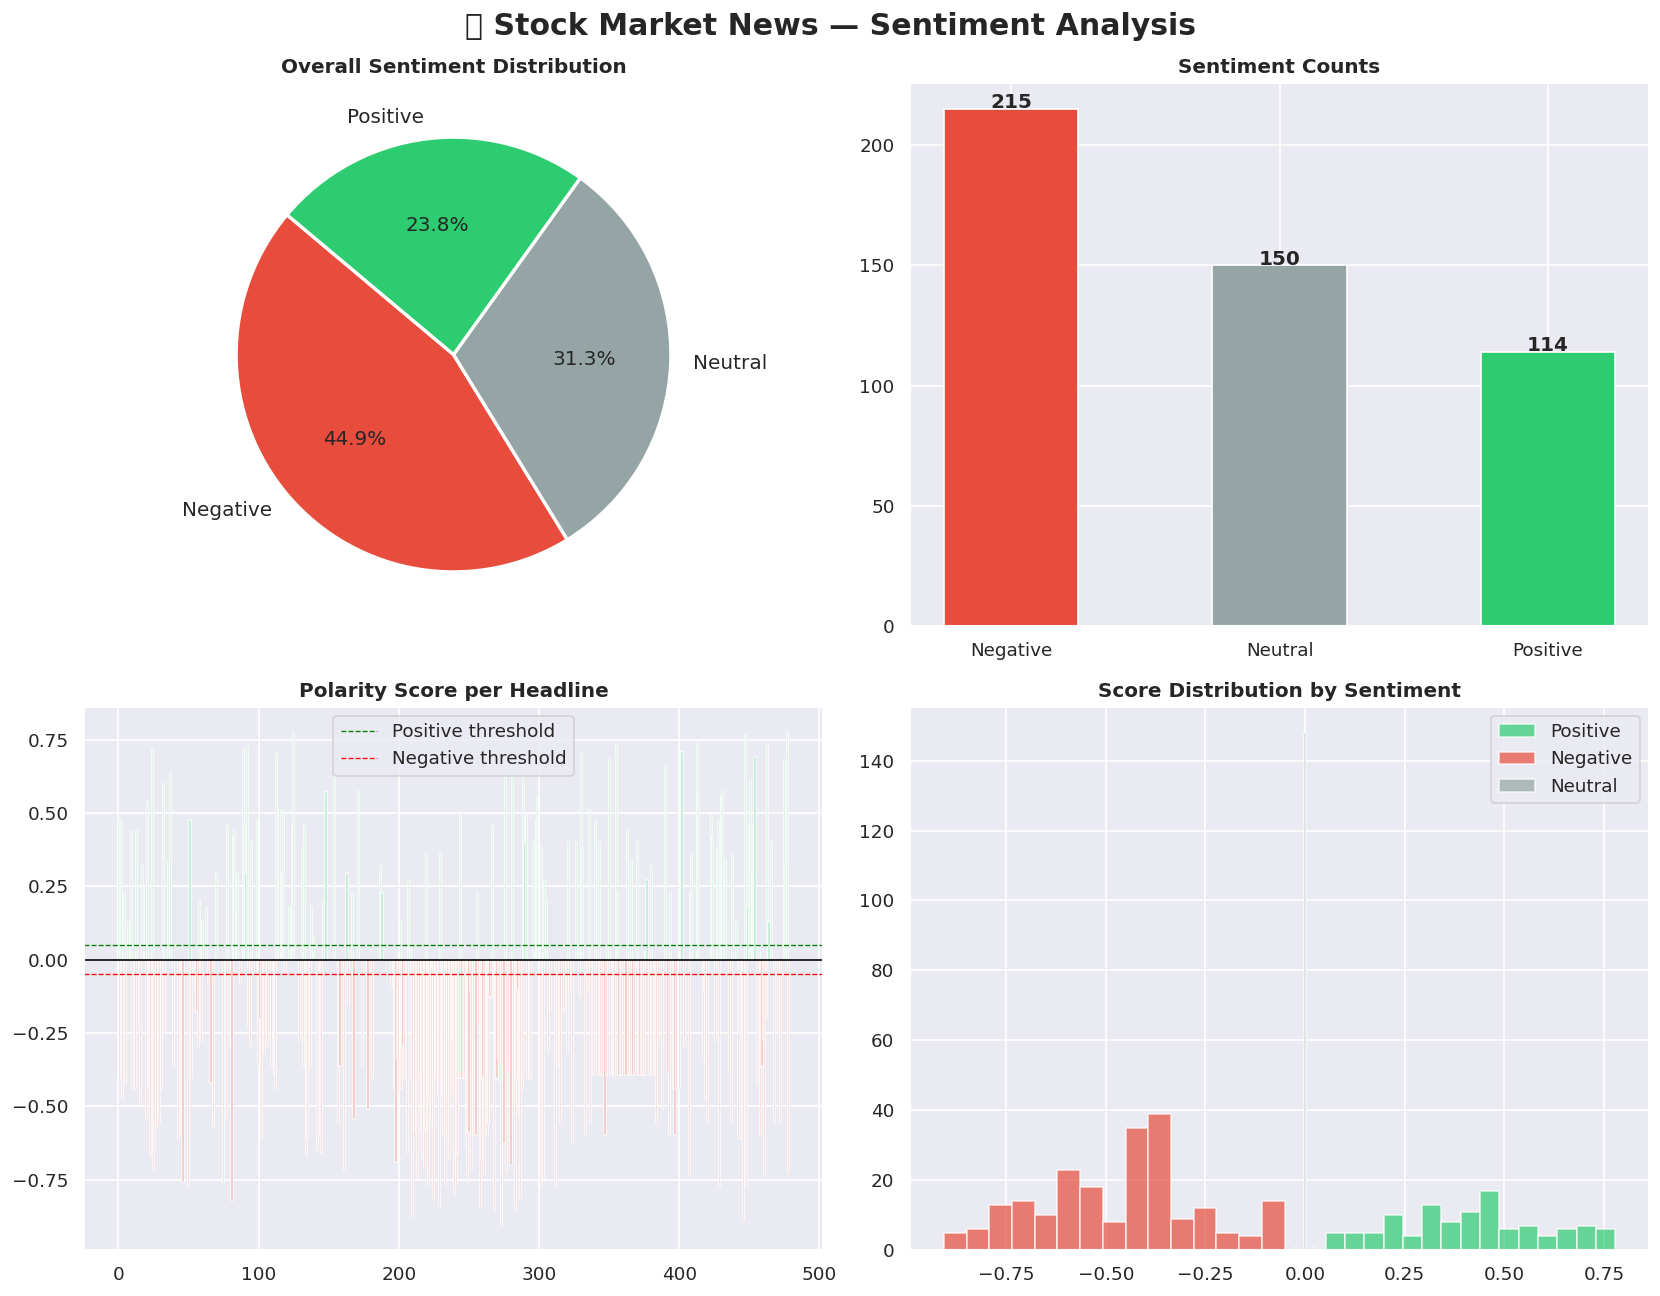

 Saved: stocks_sentiment_analysis.png


In [31]:
SENT_COLORS = {'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'}
counts = news_df['sentiment'].value_counts()

fig, axes = plt.subplots(2,2,figsize=(14,11))
fig.suptitle('💬 Stock Market News — Sentiment Analysis', fontsize=18, fontweight='bold')

colors_pie = [SENT_COLORS.get(l,'#999') for l in counts.index]
axes[0,0].pie(counts.values, labels=counts.index, colors=colors_pie, autopct='%1.1f%%',
              startangle=140, wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12})
axes[0,0].set_title('Overall Sentiment Distribution', fontweight='bold')

axes[0,1].bar(counts.index, counts.values, color=colors_pie, edgecolor='white', width=0.5)
for i,(l,v) in enumerate(zip(counts.index, counts.values)):
    axes[0,1].text(i, v+0.2, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0,1].set_title('Sentiment Counts', fontweight='bold')

bar_c = [SENT_COLORS.get(s,'#999') for s in news_df['sentiment']]
axes[1,0].bar(range(len(news_df)), news_df['vader_compound'], color=bar_c, alpha=0.8)
axes[1,0].axhline(0, color='black', lw=1)
axes[1,0].axhline(0.05, color='green', ls='--', lw=0.8, label='Positive threshold')
axes[1,0].axhline(-0.05, color='red', ls='--', lw=0.8, label='Negative threshold')
axes[1,0].set_title('Polarity Score per Headline', fontweight='bold')
axes[1,0].legend()

for sent, color in SENT_COLORS.items():
    sub = news_df[news_df['sentiment']==sent]['vader_compound']
    if not sub.empty:
        axes[1,1].hist(sub, bins=15, color=color, alpha=0.7, label=sent, edgecolor='white')
axes[1,1].set_title('Score Distribution by Sentiment', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('stocks_sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); print(' Saved: stocks_sentiment_analysis.png')

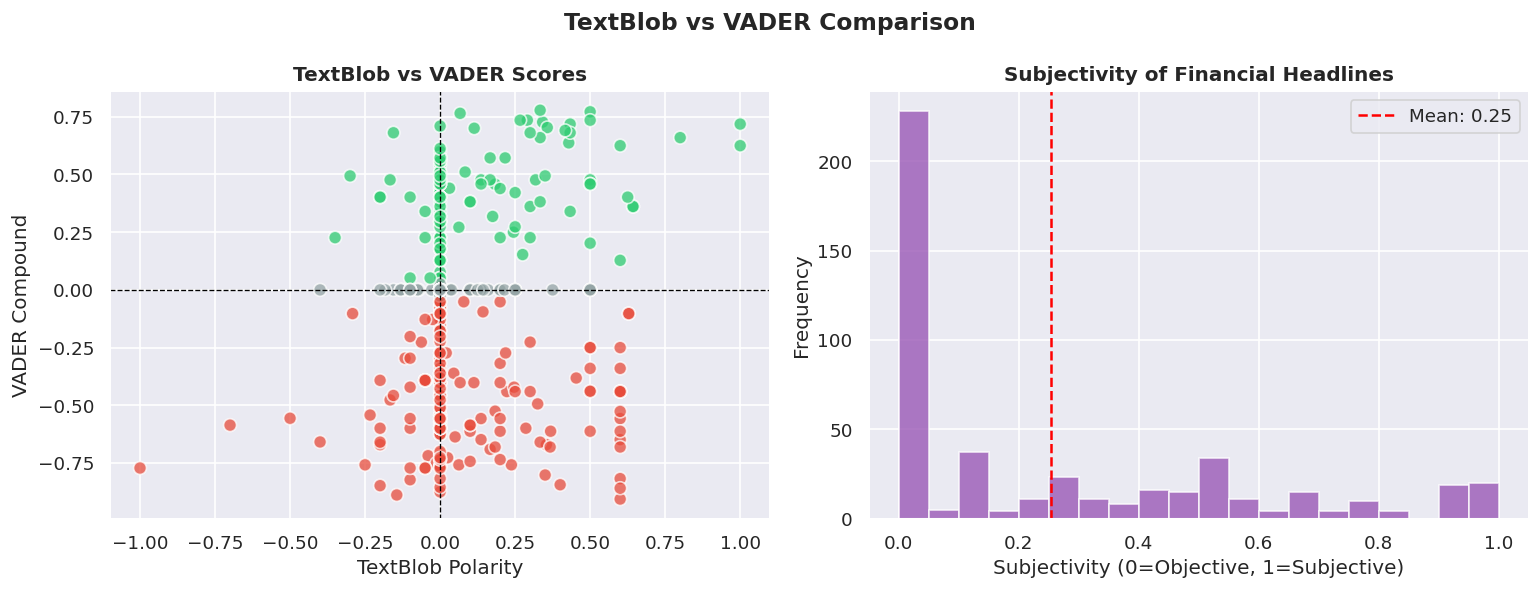

In [32]:

fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle('TextBlob vs VADER Comparison', fontsize=14, fontweight='bold')
colors_map = {'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'}
axes[0].scatter(news_df['tb_polarity'], news_df['vader_compound'],
                c=[colors_map.get(s,'grey') for s in news_df['sentiment']],
                alpha=0.75, s=60, edgecolors='white')
axes[0].axhline(0,color='black',lw=0.8,ls='--')
axes[0].axvline(0,color='black',lw=0.8,ls='--')
axes[0].set_xlabel('TextBlob Polarity'); axes[0].set_ylabel('VADER Compound')
axes[0].set_title('TextBlob vs VADER Scores', fontweight='bold')

axes[1].hist(news_df['tb_subjectivity'], bins=20, color='#9b59b6', alpha=0.8, edgecolor='white')
axes[1].axvline(news_df['tb_subjectivity'].mean(), color='red', ls='--', lw=1.5,
                label=f"Mean: {news_df['tb_subjectivity'].mean():.2f}")
axes[1].set_xlabel('Subjectivity (0=Objective, 1=Subjective)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Subjectivity of Financial Headlines', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

In [33]:
news_df.to_csv('stocks_sentiment_results.csv', index=False)
print(' Saved: stocks_sentiment_results.csv')
print()
print('Sample headlines by sentiment:')
for sent in ['Positive','Negative','Neutral']:
    sub = news_df[news_df['sentiment']==sent]
    if not sub.empty:
        print(f'[{sent}] {sub.iloc[0]["headline"][:85]}...')

 Saved: stocks_sentiment_results.csv

Sample headlines by sentiment:
[Positive] Dow surges 600 points in relief rally after Trump says U.S. and Iran have had ‘produc...
[Negative] Stock market today: Dow, S&P 500, Nasdaq futures waver as Iran officials reject negot...
[Neutral] Stock market today (March 24, 2026): Nifty50 opens above 22,800; BSE Sensex rises ove...


In [34]:
from google.colab import files

files.download('stocks_clean.csv')
files.download('stocks_dashboard.png')
files.download('stocks_sentiment_analysis.png')
files.download('stocks_sentiment_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# ✅ Project Summary

| Task | Status | Key Outputs |
|------|--------|-------------|
| Task 1: Data Collection | ✅ Done | `stocks_clean.csv` |
| Task 2: EDA | ✅ Done | Stats, correlations, hypothesis tests, volatility analysis |
| Task 3: Visualization | ✅ Done | 8 charts + `stocks_dashboard.png` |
| Task 4: Sentiment Analysis | ✅ Done | `stocks_sentiment_results.csv` + charts |

**Key Findings:**
- Opening price is an extremely strong predictor of closing price
- Volume alone does not predict daily returns
- Majority of S&P 500 stocks gained value between 2013–2018
- Financial news headlines tend to be mixed — both positive and negative

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · TextBlob · VADER · BeautifulSoup

**GitHub Repo:** `CodeAlpha_StockMarketAnalytics`